# Maternal Health Risk Prediction
## Exploratory Data Analysis (EDA)

### Project Objective

The purpose of this project is to analyze maternal health data and predict pregnancy risk levels using data mining and machine learning techniques.

This notebook focuses on the exploratory data analysis (EDA) stage of the project.

### Main Goals

- Understand the dataset structure
- Examine feature types
- Analyze missing values
- Investigate statistical properties
- Detect outliers
- Study variable distributions
- Analyze relationships between variables
- Determine preprocessing requirements

In [345]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


# Dataset Loading

In this section, the dataset is loaded into the notebook environment using pandas.

The first inspection of the dataset will help us understand:
- dataset size
- feature names
- general structure
- possible data quality issues

In [346]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("../data/Dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


# Dataset Shape

The shape of a dataset represents:
- the number of rows (observations)
- the number of columns (features)

Understanding dataset dimensions is important before starting statistical analysis and preprocessing.

In [347]:
# ============================================
# DATASET SHAPE
# ============================================

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1205, 12)


# Dataset Preview

Before performing statistical analysis, it is important to inspect the dataset structure visually.

Displaying the first rows of the dataset helps identify:
- feature names
- data formatting
- categorical variables
- potential inconsistencies
- possible preprocessing requirements

In [348]:
# ============================================
# FIRST 5 ROWS OF THE DATASET
# ============================================

df.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


# Dataset Information

Understanding the internal structure of the dataset is essential before applying statistical analysis and machine learning techniques.

This section provides information about:
- column names
- data types
- non-null counts
- memory usage

The analysis helps identify:
- categorical variables
- numerical variables
- missing values
- preprocessing requirements

In [349]:
# ============================================
# DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   object 
dtypes: float64(7), int64(4), object(1)
memory usage: 113.1+ KB


## Structural Analysis Observations

- The dataset contains both integer and floating-point numerical variables.
- The target variable is categorical and will require encoding before model training.
- Binary medical indicators appear to be represented numerically.
- Further inspection is necessary to identify missing values and potential inconsistencies.

# Missing Value Analysis

Missing values are a critical issue in data mining and machine learning projects because they may:
- reduce model performance
- introduce bias
- affect statistical validity

This section analyzes the amount and distribution of missing values in the dataset.

Both the count and percentage of missing values will be examined.

In [350]:
# ============================================
# MISSING VALUE COUNTS
# ============================================

missing_values = df.isnull().sum()

missing_values

Age                        0
Systolic BP                5
Diastolic                  4
BS                         2
Body Temp                  0
BMI                       18
Previous Complications     2
Preexisting Diabetes       2
Gestational Diabetes       0
Mental Health              0
Heart Rate                 2
Risk Level                18
dtype: int64

In [351]:
# ============================================
# MISSING VALUE PERCENTAGES
# ============================================

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Risk Level                1.493776
BMI                       1.493776
Systolic BP               0.414938
Diastolic                 0.331950
Heart Rate                0.165975
BS                        0.165975
Preexisting Diabetes      0.165975
Previous Complications    0.165975
Age                       0.000000
Body Temp                 0.000000
Mental Health             0.000000
Gestational Diabetes      0.000000
dtype: float64

## Missing Value Observations

- Several variables contain missing values.
- BMI and Risk Level contain the highest number of missing observations.
- Missing data in the target variable is especially important because it may directly affect classification performance.
- The proportion of missing data appears relatively low, which may allow preprocessing strategies such as row removal or statistical imputation.

# Missing Value Visualization

Visualizing missing values helps identify the distribution of incomplete observations across features.

Graphical analysis makes it easier to:
- compare missing value frequencies
- identify problematic variables
- support preprocessing decisions

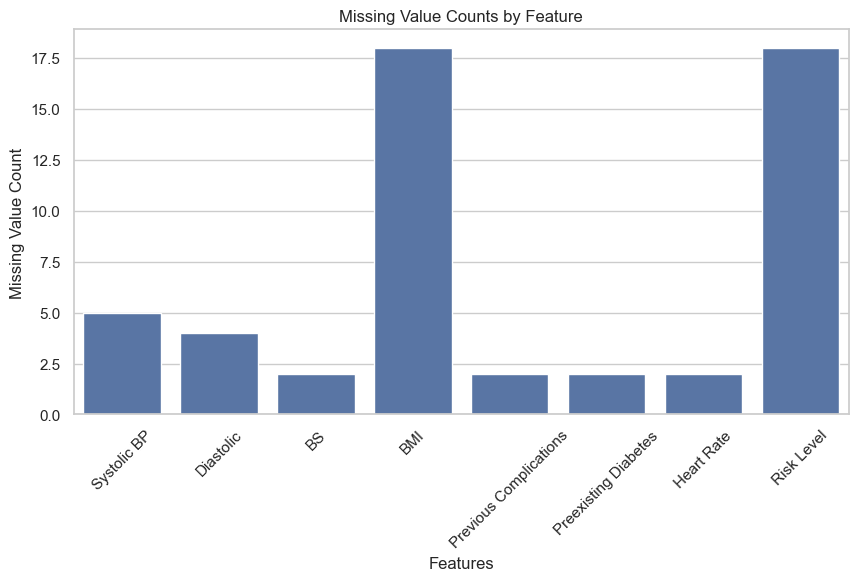

In [352]:
# ============================================
# MISSING VALUE VISUALIZATION
# ============================================

missing_counts = df.isnull().sum()

# Keep only columns with missing values
missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_counts.index,
    y=missing_counts.values
)

plt.title("Missing Value Counts by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Value Count")

plt.xticks(rotation=45)

plt.show()

## Visualization Observations

- BMI and Risk Level contain the highest number of missing observations.
- Most variables contain very few missing values.
- The overall missing value distribution appears limited and manageable.
- No feature appears to contain critically large amounts of missing data.

# Statistical Summary

Statistical summaries provide important insights into the numerical properties of the dataset.

This analysis helps identify:
- central tendency
- variability
- possible outliers
- unusual distributions
- abnormal ranges

The summary statistics include:
- mean
- standard deviation
- minimum and maximum values
- quartiles

In [353]:
# ============================================
# DESCRIPTIVE STATISTICS
# ============================================

df.describe()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
count,1205.000000,1200.000000,1201.000000,1203.000000,1205.000000,1187.000000,1203.000000,1203.000000,1205.000000,1205.00000,1203.000000
mean,27.482988,116.819167,77.166528,7.501064,98.395851,23.315080,0.175395,0.288446,0.117842,0.33444,75.817124
std,9.196765,18.715502,14.305148,3.049522,1.088363,3.875682,0.380463,0.453228,0.322555,0.47199,7.227338
min,10.000000,70.000000,40.000000,3.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.00000,58.000000
25%,21.000000,100.000000,65.000000,6.000000,98.000000,20.450000,0.000000,0.000000,0.000000,0.00000,70.000000
50%,25.000000,120.000000,80.000000,6.900000,98.000000,23.000000,0.000000,0.000000,0.000000,0.00000,76.000000
75%,31.000000,130.000000,90.000000,7.900000,98.000000,25.000000,0.000000,1.000000,0.000000,1.00000,80.000000
max,65.000000,200.000000,140.000000,19.000000,103.000000,37.000000,1.000000,1.000000,1.000000,1.00000,92.000000


## Statistical Summary Observations

- The average maternal age in the dataset is approximately 27 years, indicating that most observations belong to young adult pregnancies.
- Several variables contain potentially extreme values, such as systolic blood pressure reaching 200 and blood sugar reaching 19.
- The BMI feature contains a minimum value of 0, which may indicate invalid or incorrectly recorded observations.
- Binary medical indicators can also be interpreted statistically through their mean values, which approximately represent the proportion of positive cases.
- The presence of extreme values suggests that additional outlier analysis may be necessary before model training.

# Target Variable Analysis

The target variable is one of the most important components of a classification problem.

Analyzing the distribution of target classes helps determine:
- class balance
- potential bias
- classification difficulty
- preprocessing requirements

Imbalanced target distributions may negatively affect model performance and evaluation reliability.

In [354]:
# ============================================
# TARGET VARIABLE COUNTS
# ============================================

df["Risk Level"].value_counts()

Risk Level
Low     713
High    474
Name: count, dtype: int64

In [355]:
# ============================================
# TARGET VARIABLE PERCENTAGES
# ============================================

target_percentage = (
    df["Risk Level"]
    .value_counts(normalize=True) * 100
)

target_percentage

Risk Level
Low     60.067397
High    39.932603
Name: proportion, dtype: float64

# Target Variable Visualization

Visualizing the target distribution provides a clearer understanding of class balance within the dataset.

Balanced datasets generally allow machine learning models to learn both classes more effectively.

Severely imbalanced datasets may require additional preprocessing techniques such as:
- resampling
- class weighting
- synthetic data generation

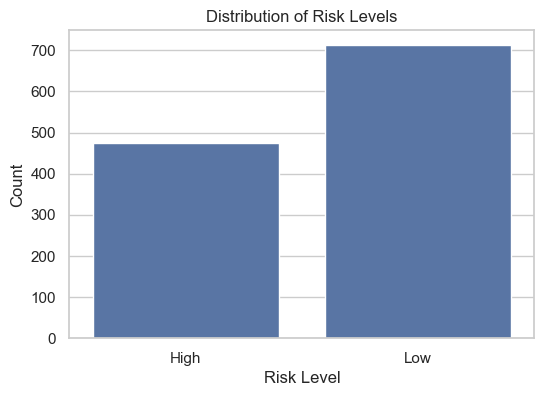

In [356]:
# ============================================
# TARGET VARIABLE VISUALIZATION
# ============================================

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Risk Level"
)

plt.title("Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Count")

plt.show()

## Target Variable Observations

- The dataset shows a moderately imbalanced class distribution.
- Approximately 60% of observations belong to the Low risk class, while 40% belong to the High risk class.
- The imbalance does not appear severe enough to require aggressive resampling techniques.
- However, relying only on accuracy may produce misleading evaluation results.
- Additional evaluation metrics such as precision, recall, F1-score, and confusion matrices should be considered during model evaluation.

# Feature Distribution Analysis

Understanding feature distributions is essential in statistical analysis and machine learning.

Distribution analysis helps identify:
- skewness
- concentration of values
- spread of observations
- potential outliers
- abnormal patterns

These insights are important for selecting appropriate preprocessing and modeling techniques.

## Age Distribution Analysis

Maternal age is an important medical factor in pregnancy risk assessment.

Analyzing the distribution of age values may help identify:
- dominant age groups
- age concentration
- variability
- extreme maternal ages

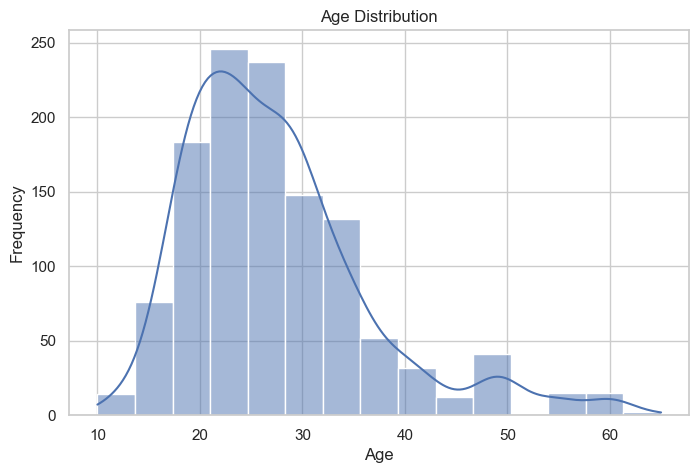

In [357]:
# ============================================
# AGE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Age"],
    bins=15,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

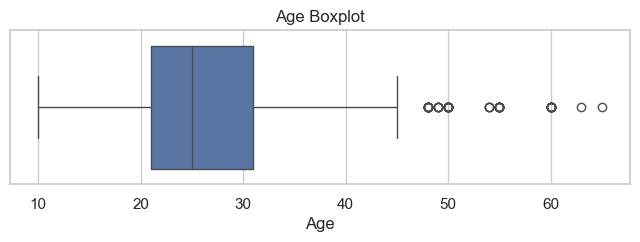

In [358]:
# ============================================
# AGE BOXPLOT
# ============================================

plt.figure(figsize=(8, 2))

sns.boxplot(
    x=df["Age"]
)

plt.title("Age Boxplot")

plt.show()

## Age Distribution Observations

- The age distribution appears moderately right-skewed.
- Most observations are concentrated between approximately 20 and 30 years of age.
- The distribution suggests that the dataset primarily represents young adult pregnancies.
- Several higher-age observations appear in the boxplot as potential outliers.
- These extreme age values may represent high-risk pregnancies rather than data errors.
- The presence of a longer right tail indicates positive skewness in the age distribution.

## BMI Distribution Analysis

Body Mass Index (BMI) is an important health indicator that may significantly influence pregnancy risk.

Analyzing BMI distribution helps identify:
- concentration of BMI values
- spread of observations
- abnormal BMI values
- potential outliers
- preprocessing requirements

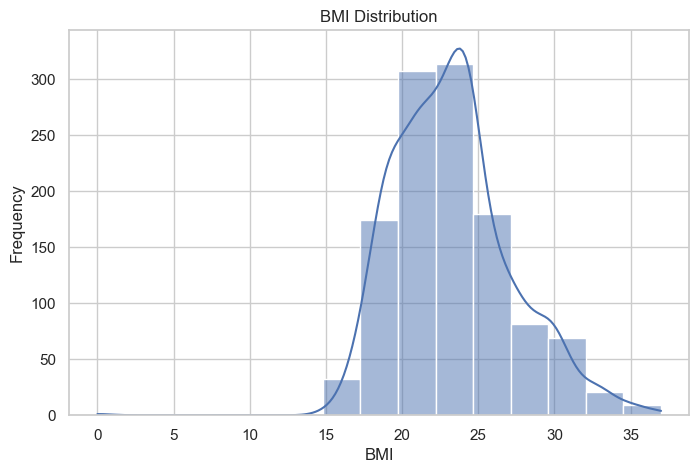

In [359]:
# ============================================
# BMI DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["BMI"],
    bins=15,
    kde=True
)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

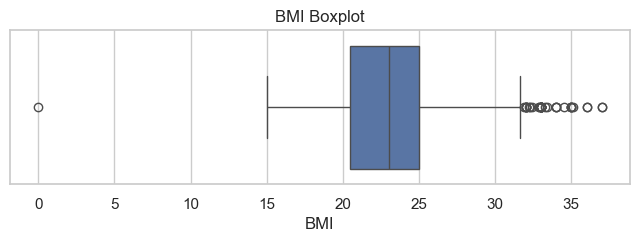

In [360]:
# ============================================
# BMI BOXPLOT
# ============================================

plt.figure(figsize=(8, 2))

sns.boxplot(
    x=df["BMI"]
)

plt.title("BMI Boxplot")

plt.show()

## BMI Distribution Observations

- The BMI distribution appears moderately right-skewed.
- Most BMI values are concentrated between approximately 20 and 26.
- The longer right tail suggests the presence of higher BMI observations within the dataset.
- Several upper-range BMI values appear as potential outliers in the boxplot.
- These outliers may represent obesity-related pregnancy risks rather than incorrect observations.
- A BMI value of 0 appears in the dataset and is medically invalid.
- The BMI value of 0 may indicate a missing placeholder or data entry issue and may require special preprocessing treatment.

## Blood Pressure Distribution Analysis

Blood pressure is one of the most important medical indicators in maternal health assessment.

Both systolic and diastolic blood pressure measurements may help identify:
- hypertension risk
- abnormal cardiovascular conditions
- pregnancy-related complications
- extreme medical observations

Distribution analysis may also reveal skewness and potential outliers in blood pressure measurements.

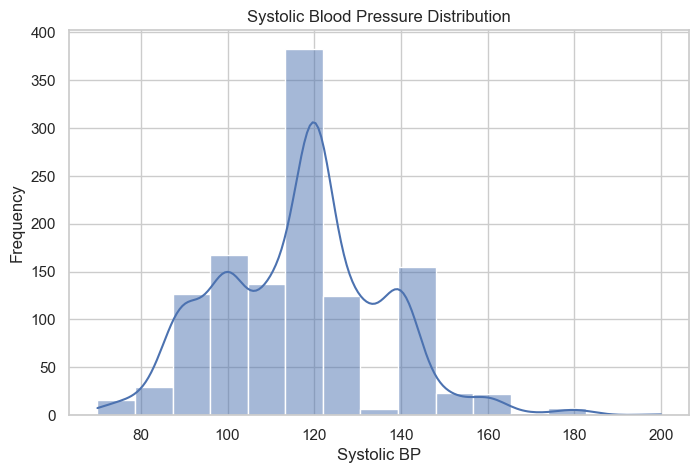

In [361]:
# ============================================
# SYSTOLIC BLOOD PRESSURE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Systolic BP"],
    bins=15,
    kde=True
)

plt.title("Systolic Blood Pressure Distribution")
plt.xlabel("Systolic BP")
plt.ylabel("Frequency")

plt.show()

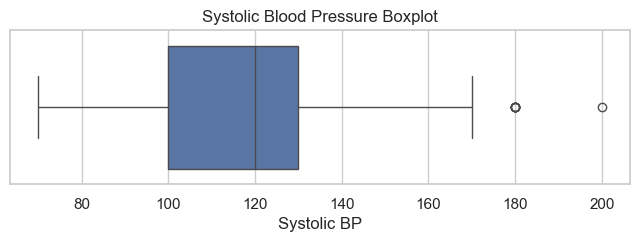

In [362]:
# ============================================
# SYSTOLIC BLOOD PRESSURE BOXPLOT
# ============================================

plt.figure(figsize=(8, 2))

sns.boxplot(
    x=df["Systolic BP"]
)

plt.title("Systolic Blood Pressure Boxplot")

plt.show()

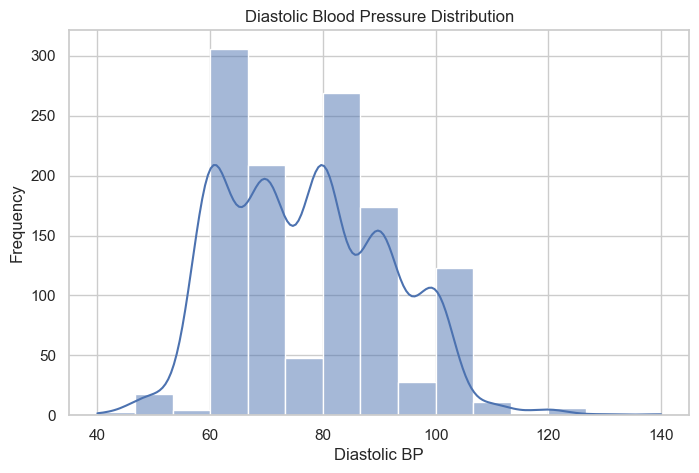

In [363]:
# ============================================
# DIASTOLIC BLOOD PRESSURE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Diastolic"],
    bins=15,
    kde=True
)

plt.title("Diastolic Blood Pressure Distribution")
plt.xlabel("Diastolic BP")
plt.ylabel("Frequency")

plt.show()

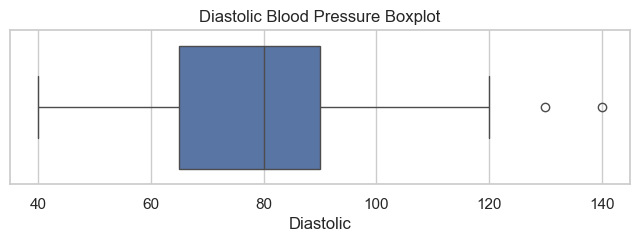

In [364]:
# ============================================
# DIASTOLIC BLOOD PRESSURE BOXPLOT
# ============================================

plt.figure(figsize=(8, 2))

sns.boxplot(
    x=df["Diastolic"]
)

plt.title("Diastolic Blood Pressure Boxplot")

plt.show()

## Blood Pressure Distribution Observations

- Both systolic and diastolic blood pressure distributions appear moderately right-skewed.
- Most observations are concentrated within clinically common blood pressure ranges.
- Several extreme blood pressure values appear in the upper ranges of both distributions.
- Systolic blood pressure values around 180–200 and diastolic values around 130–140 appear as potential outliers.
- These extreme observations may represent severe hypertension-related pregnancy risks rather than invalid measurements.
- The presence of higher blood pressure observations may improve the predictive capability of classification models for high-risk pregnancies.

# Correlation Analysis

Correlation analysis helps measure the strength and direction of relationships between numerical variables.

Understanding feature correlations is important for:
- detecting linear relationships
- identifying feature dependencies
- recognizing multicollinearity
- improving feature selection decisions

Correlation coefficients range between:
- -1 → strong negative relationship
-  0 → no linear relationship
- +1 → strong positive relationship

In [365]:
# ============================================
# CORRELATION MATRIX
# ============================================

correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
Age,1.000000,0.243273,0.236292,0.601590,-0.111804,0.337543,0.208073,0.260488,-0.058400,0.123865,0.123010
Systolic BP,0.243273,1.000000,0.794367,0.342867,-0.180579,0.287323,0.133681,0.165559,0.138124,0.185136,0.156363
Diastolic,0.236292,0.794367,1.000000,0.362001,-0.119554,0.272607,0.183074,0.193900,0.157292,0.195837,0.166879
BS,0.601590,0.342867,0.362001,1.000000,0.079947,0.495053,0.425019,0.552853,0.112881,0.382315,0.299087
Body Temp,-0.111804,-0.180579,-0.119554,0.079947,1.000000,0.022687,0.115034,0.070370,0.155650,0.134961,0.097998
BMI,0.337543,0.287323,0.272607,0.495053,0.022687,1.000000,0.371097,0.293221,0.316977,0.323948,0.217658
Previous Complications,0.208073,0.133681,0.183074,0.425019,0.115034,0.371097,1.000000,0.367340,0.210641,0.452851,0.278664
Preexisting Diabetes,0.260488,0.165559,0.193900,0.552853,0.070370,0.293221,0.367340,1.000000,-0.045262,0.433341,0.375282
Gestational Diabetes,-0.058400,0.138124,0.157292,0.112881,0.155650,0.316977,0.210641,-0.045262,1.000000,0.242823,0.187212
Mental Health,0.123865,0.185136,0.195837,0.382315,0.134961,0.323948,0.452851,0.433341,0.242823,1.000000,0.326424


# Correlation Heatmap

Heatmaps provide a visual representation of correlation strengths between variables.

Darker or more intense colors indicate stronger relationships between features.

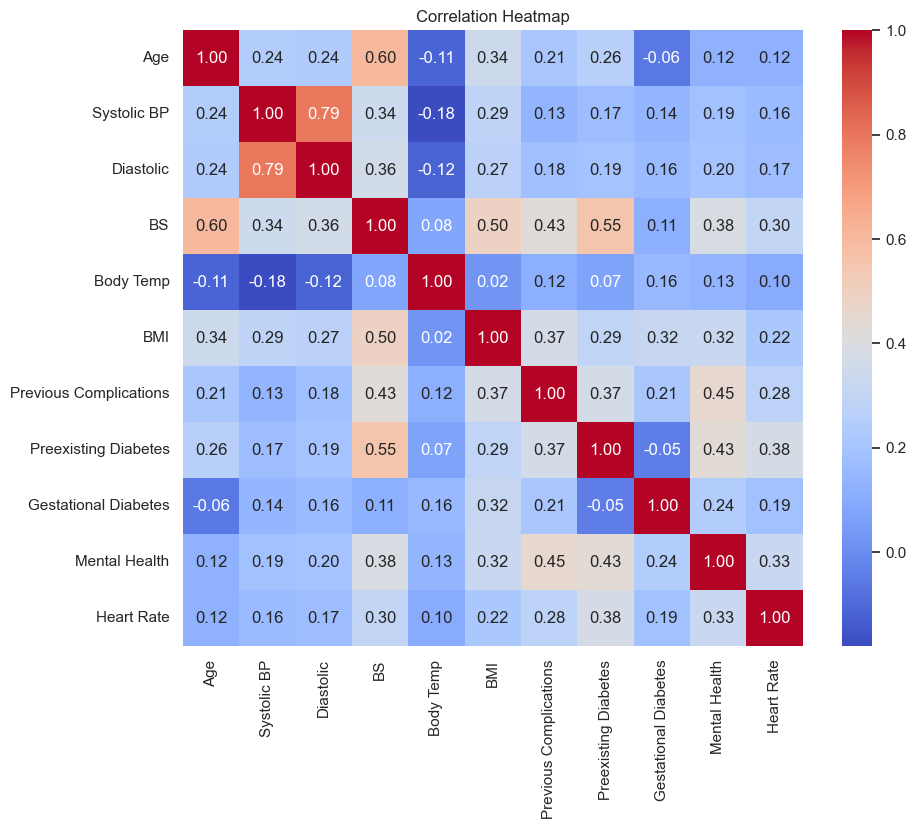

In [366]:
# ============================================
# CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Correlation Analysis Observations

- Systolic and diastolic blood pressure show a strong positive correlation (approximately 0.79), which is medically expected because both variables represent related cardiovascular measurements.
- Age and blood sugar levels also demonstrate a moderately strong positive correlation, suggesting that increased maternal age may be associated with higher blood sugar levels.
- Blood sugar and preexisting diabetes exhibit a meaningful positive relationship, indicating internal consistency within the dataset.
- Several moderate correlations exist among health-related variables, suggesting interconnected maternal health factors.
- Body temperature shows relatively weak correlations with most variables, which may indicate lower predictive relevance.
- No extremely high correlations (greater than 0.80) were observed, suggesting that severe multicollinearity may not be a major issue in the dataset.
- Correlation does not imply causation, and these relationships should be interpreted carefully within the medical context.

# Risk-Level-Based Feature Analysis

Analyzing features according to maternal risk groups helps determine whether numerical variables differ across classes.

This type of analysis is important for:
- understanding class separation
- identifying predictive features
- evaluating feature relevance for classification models

Features that show noticeable differences between risk groups may contribute more effectively to prediction performance.

## Blood Sugar Analysis by Risk Level

Blood sugar levels are medically associated with diabetes and pregnancy complications.

Comparing blood sugar distributions across risk groups may reveal whether elevated blood sugar is linked to higher maternal risk levels.

In [367]:
# ============================================
# BLOOD SUGAR STATISTICS BY RISK LEVEL
# ============================================

df.groupby("Risk Level")["BS"].describe()

,count,mean,std,min,25%,50%,75%,max
Risk Level,,,,,,,,
High,473.0,9.734271,3.533589,3.8,7.2,9.0,11.0,19.0
Low,713.0,6.045119,1.342426,3.0,5.0,6.6,6.9,15.0


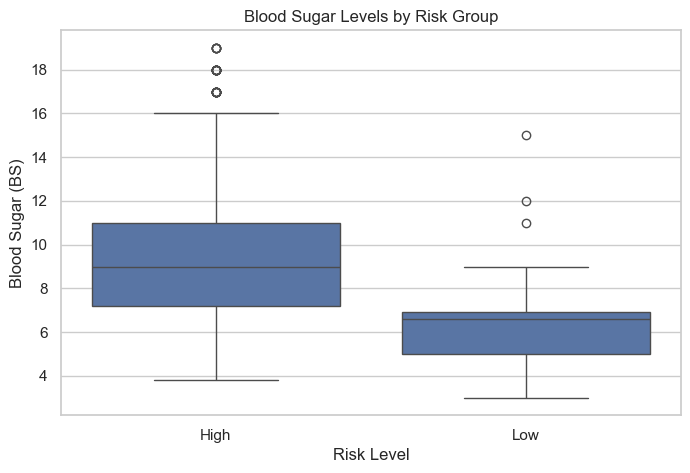

In [368]:
# ============================================
# BLOOD SUGAR DISTRIBUTION BY RISK LEVEL
# ============================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Risk Level",
    y="BS"
)

plt.title("Blood Sugar Levels by Risk Group")
plt.xlabel("Risk Level")
plt.ylabel("Blood Sugar (BS)")

plt.show()

## Blood Sugar Risk-Level Observations

- High-risk pregnancies show substantially higher blood sugar levels compared to low-risk pregnancies.
- The mean blood sugar value is significantly higher in the High risk group.
- Median values also differ considerably between groups, indicating that the observed difference is not driven only by extreme outliers.
- The High risk group demonstrates greater variability and a wider distribution of blood sugar values.
- Several extreme blood sugar observations appear within the High risk group, potentially representing severe diabetic or pregnancy-related complications.
- Blood sugar appears to be a strong candidate feature for maternal risk prediction models.

## Blood Pressure Analysis by Risk Level

Blood pressure measurements are closely associated with maternal health risks and pregnancy complications.

Comparing blood pressure values across risk groups may help determine whether hypertension-related patterns exist within the dataset.

In [369]:
# ============================================
# SYSTOLIC BP STATISTICS BY RISK LEVEL
# ============================================

df.groupby("Risk Level")["Systolic BP"].describe()

,count,mean,std,min,25%,50%,75%,max
Risk Level,,,,,,,,
High,474.0,123.50211,21.629520,70.0,110.0,120.0,140.0,200.0
Low,709.0,112.38787,14.878621,70.0,100.0,120.0,120.0,160.0


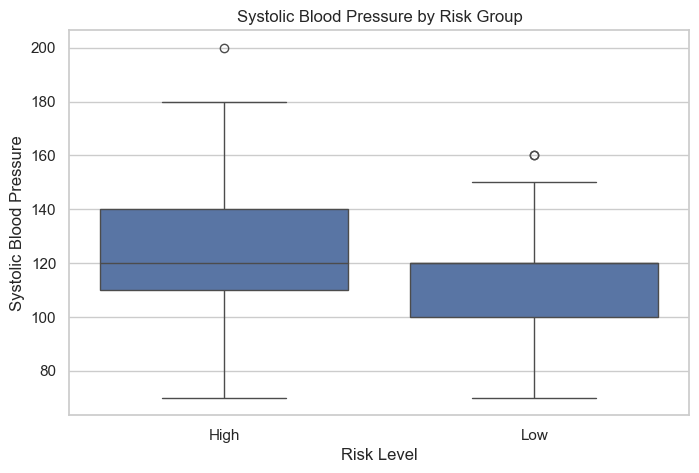

In [370]:
# ============================================
# SYSTOLIC BP BY RISK LEVEL
# ============================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Risk Level",
    y="Systolic BP"
)

plt.title("Systolic Blood Pressure by Risk Group")
plt.xlabel("Risk Level")
plt.ylabel("Systolic Blood Pressure")

plt.show()

In [371]:
# ============================================
# DIASTOLIC BP STATISTICS BY RISK LEVEL
# ============================================

df.groupby("Risk Level")["Diastolic"].describe()

,count,mean,std,min,25%,50%,75%,max
Risk Level,,,,,,,,
High,474.0,83.027426,15.741479,40.0,70.0,90.0,95.0,140.0
Low,711.0,73.329114,11.705963,49.0,63.0,70.0,80.0,120.0


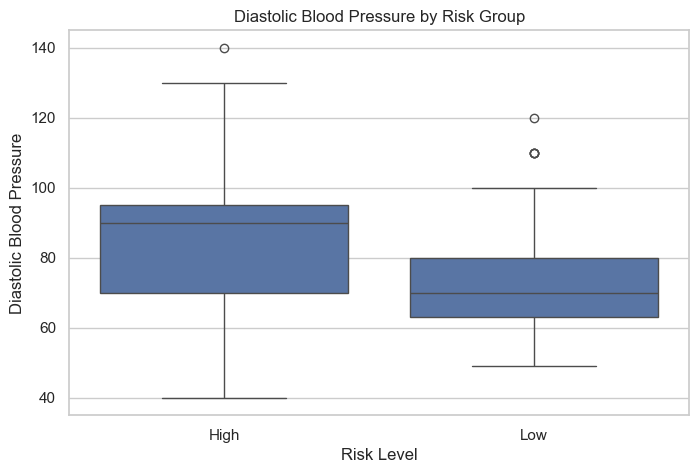

In [372]:
# ============================================
# DIASTOLIC BP BY RISK LEVEL
# ============================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Risk Level",
    y="Diastolic"
)

plt.title("Diastolic Blood Pressure by Risk Group")
plt.xlabel("Risk Level")
plt.ylabel("Diastolic Blood Pressure")

plt.show()

## Blood Pressure Risk-Level Observations

- High-risk pregnancies exhibit higher systolic and diastolic blood pressure values compared to low-risk pregnancies.
- The mean systolic blood pressure is noticeably higher within the High risk group.
- Diastolic blood pressure demonstrates particularly strong separation between risk classes, with a substantially higher median value in the High risk group.
- The High risk group also shows greater variability and wider blood pressure ranges.
- Several extreme blood pressure observations appear among high-risk pregnancies, potentially representing severe hypertensive conditions.
- Blood pressure measurements appear to be important predictive features for maternal risk classification.

# Statistical Hypothesis Testing

Statistical hypothesis testing is used to determine whether observed differences between groups are statistically significant.

In this section, independent sample t-tests will be applied to compare numerical features across maternal risk groups.

The null hypothesis assumes that there is no difference between the group means.

A p-value lower than 0.05 will be considered statistically significant.

In [373]:
# ============================================
# IMPORT STATISTICAL TESTING LIBRARY
# ============================================

from scipy.stats import ttest_ind

## Blood Sugar T-Test

This test evaluates whether blood sugar levels differ significantly between High-risk and Low-risk pregnancies.

In [374]:
# ============================================
# SPLIT BLOOD SUGAR VALUES BY RISK GROUP
# ============================================

high_risk_bs = df[df["Risk Level"] == "High"]["BS"]

low_risk_bs = df[df["Risk Level"] == "Low"]["BS"]

In [375]:
# ============================================
# INDEPENDENT T-TEST FOR BLOOD SUGAR
# ============================================

t_statistic, p_value = ttest_ind(
    high_risk_bs,
    low_risk_bs,
    nan_policy="omit"
)

print("T-Statistic:", t_statistic)
print("P-Value:", p_value)

T-Statistic: 25.268275627247732
P-Value: 5.049964168117939e-113


## Blood Sugar T-Test Observations

- The independent samples t-test produced an extremely small p-value, far below the significance threshold of 0.05.
- Therefore, the null hypothesis is rejected.
- This result indicates that blood sugar levels differ significantly between High-risk and Low-risk pregnancies.
- The large t-statistic suggests a substantial separation between the two groups.
- Blood sugar appears to be a statistically significant predictive feature for maternal risk classification.
- The probability that this difference occurred randomly is extremely low.

# Effect Size Analysis

While p-values indicate whether differences are statistically significant, effect size measures the magnitude of those differences.

Cohen’s d is commonly used to evaluate practical significance between two groups.

General interpretation:
- 0.2 → small effect
- 0.5 → medium effect
- 0.8 or greater → large effect

In [376]:
# ============================================
# COHEN'S D FOR BLOOD SUGAR
# ============================================

# Mean values
mean_high = high_risk_bs.mean()
mean_low = low_risk_bs.mean()

# Standard deviations
std_high = high_risk_bs.std()
std_low = low_risk_bs.std()

# Sample sizes
n_high = high_risk_bs.count()
n_low = low_risk_bs.count()

# Pooled standard deviation
pooled_std = np.sqrt(
    (
        ((n_high - 1) * std_high ** 2) +
        ((n_low - 1) * std_low ** 2)
    ) / (n_high + n_low - 2)
)

# Cohen's d
cohens_d = (mean_high - mean_low) / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: 1.4984512376292667


## Cohen’s d Observations for Blood Sugar

- The calculated Cohen’s d value is substantially greater than 0.8, indicating a very large effect size.
- This suggests that the difference in blood sugar levels between High-risk and Low-risk pregnancies is not only statistically significant but also practically significant.
- The large effect size indicates strong separation between the two maternal risk groups.
- Blood sugar appears to have strong predictive potential for maternal risk classification models.
- Both statistical significance and practical significance support the relevance of blood sugar as an important feature in the dataset.

# Normality Testing

Many statistical methods assume that numerical variables follow an approximately normal distribution.

This section evaluates the normality of blood sugar values using:
- the Shapiro-Wilk statistical test
- QQ plots for visual inspection

It is important to note that normality tests can become highly sensitive with large sample sizes.

In [377]:
# ============================================
# IMPORT NORMALITY TESTING LIBRARIES
# ============================================

from scipy.stats import shapiro
import scipy.stats as stats

In [378]:
# ============================================
# SHAPIRO-WILK TEST (HIGH RISK BS)
# ============================================

shapiro_high = shapiro(
    high_risk_bs.dropna().sample(400, random_state=42)
)

print("High Risk Shapiro Test:")
print(shapiro_high)

High Risk Shapiro Test:
ShapiroResult(statistic=np.float64(0.9270135658290636), pvalue=np.float64(4.692006382853613e-13))


In [379]:
# ============================================
# SHAPIRO-WILK TEST (LOW RISK BS)
# ============================================

shapiro_low = shapiro(
    low_risk_bs.dropna().sample(400, random_state=42)
)

print("Low Risk Shapiro Test:")
print(shapiro_low)

Low Risk Shapiro Test:
ShapiroResult(statistic=np.float64(0.8828948949894095), pvalue=np.float64(7.028416078961901e-17))


# QQ Plot Analysis

QQ plots visually compare the observed distribution against a theoretical normal distribution.

Points closely following the diagonal line indicate approximate normality.

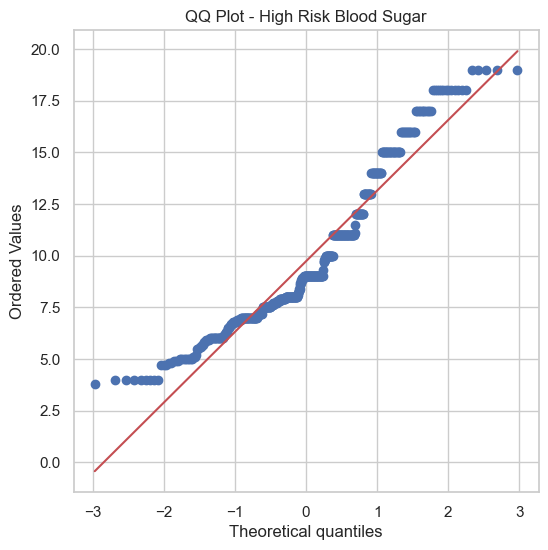

In [380]:
# ============================================
# QQ PLOT - HIGH RISK BS
# ============================================

plt.figure(figsize=(6, 6))

stats.probplot(
    high_risk_bs.dropna(),
    dist="norm",
    plot=plt
)

plt.title("QQ Plot - High Risk Blood Sugar")

plt.show()

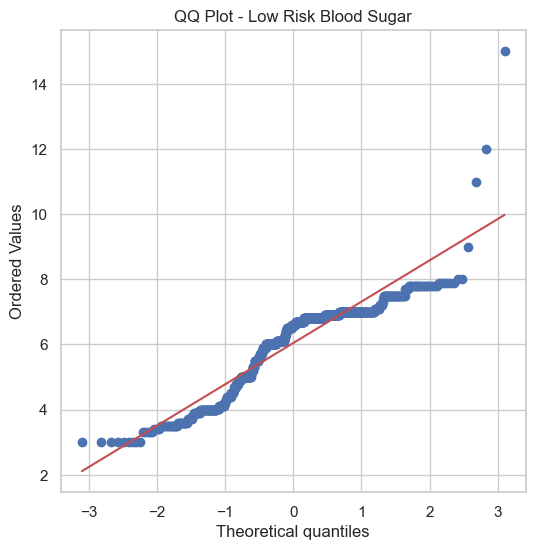

In [381]:
# ============================================
# QQ PLOT - LOW RISK BS
# ============================================

plt.figure(figsize=(6, 6))

stats.probplot(
    low_risk_bs.dropna(),
    dist="norm",
    plot=plt
)

plt.title("QQ Plot - Low Risk Blood Sugar")

plt.show()

## Normality Testing Observations

- The QQ plots indicate moderate deviations from a perfectly normal distribution, particularly within the upper tails of the blood sugar distributions.
- The High risk group demonstrates noticeable right-skewness due to several elevated blood sugar observations.
- The Shapiro-Wilk test produced very small p-values, leading to rejection of the null hypothesis of perfect normality.
- However, it is important to note that normality tests become highly sensitive with large sample sizes and may reject distributions with only minor deviations.
- Visual inspection suggests that the distributions are reasonably suitable for statistical analysis.
- Independent t-tests are generally robust against moderate deviations from normality when sample sizes are large.

# Preprocessing Decisions

Before model training, several preprocessing decisions must be made to ensure data quality and model reliability.

This section summarizes the preprocessing strategies selected based on the exploratory data analysis findings.

The following aspects are considered:
- missing value handling
- categorical encoding
- feature scaling
- outlier treatment
- train-test splitting strategy

## Missing Value Handling Strategy

The dataset contains a relatively small proportion of missing values.

Since the percentage of missing observations is low, statistical imputation methods may be preferred instead of removing large portions of data.

Possible preprocessing strategies include:
- mean or median imputation for numerical variables
- removing rows with missing target labels
- preserving as much information as possible

## Categorical Encoding Strategy

The target variable ("Risk Level") is categorical and must be converted into numerical form before machine learning model training.

A label encoding strategy may be applied:
- High → 1
- Low → 0

This transformation enables classification algorithms to process the target variable correctly.

## Feature Scaling Strategy

The numerical features within the dataset exist on different scales.

For example:
- blood pressure values
- body temperature
- BMI
- blood sugar levels

Scaling techniques such as StandardScaler may improve the performance of distance-based and gradient-based machine learning algorithms.

Tree-based models may be less sensitive to feature scaling.

## Outlier Treatment Strategy

Several numerical variables contain medically extreme observations.

However, these outliers may represent realistic high-risk maternal conditions rather than measurement errors.

Therefore, outlier removal should be approached carefully to avoid losing clinically meaningful information.

Possible strategies include:
- retaining medically realistic observations
- applying robust scaling methods
- evaluating model sensitivity to extreme values

## Train-Test Split Strategy

The dataset will be divided into training and testing subsets before model development.

A stratified split strategy may be preferred to preserve the class distribution of maternal risk levels across both datasets.

Using a fixed random state improves reproducibility and experimental consistency.

# Modeling Preparation Observations

The exploratory data analysis process revealed several important findings:

- Blood sugar and blood pressure variables show strong relationships with maternal risk levels.
- Multiple statistically significant differences exist between High-risk and Low-risk pregnancies.
- Several features demonstrate strong predictive potential for classification tasks.
- Missing value proportions are relatively low and manageable.
- Moderate deviations from normality are present, although large sample sizes support robust statistical analysis.
- The dataset appears suitable for machine learning classification modeling.